In [1]:
import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path

##########################################################
# Initialize parameters  
##########################################################

# data file for leakage current (reset disabled)
filename = "/data/fromlabpix/cold/packet-cold_leakage_4tiles_cds-2025_10_29_01_31_09_PDT.h5" # Cold leakage. No channels disabled

# this date must match the date on the pedesal filename
pedestal_file_date = '2025-11-25'

# the tile # is listed on the tile just above the flat data cable connection to the pacman
tiles = [1,2,3,4,5]
chip_serial_number_list = ['', '4k02056', '4k02533', '4k03591', '4k01892', '4k03537']
ntiles = 5

# if only 4 tiles were tested (as indicated in the file name) input the serial #s here
#if "4tiles" in filename:
#    tiles = [1,2,3,4]
#    chip_serial_number_list = ['', '4k02056', '4k02533', '4k03591', '4k03537']
#    ntiles = 4

# pedestals will be read in from a datafile
pedestals = [[[0 for chn in range(64)] for chp in range(171)] for tile in range(6)] 

# the number of standard deviations to qualify a dataword as "high" to identify potential leakage candidates
nstdev = 3

# Setting verbose = True will print out various pieces of chip-level or packet-level information 
verbose = False

# initialize
ig = 1 
first_tile = True
n_chan56 = 0
chan56_stdev = []
n_high_file = 0
mean_of_means = [] 
means = [[] for ch in range(64)]
chan_list = []
stdev_high_list = []
noisy_count, leakage_count = 0,0

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20]
                     ]
    
    return io_ch_per_tile[tile]


In [3]:
def get_data(filename, tile, ig):
    
    global chip_serial_number, first_tile, n_chan56, n_high_file, chan56_stdev, nstdev, mean_of_means, stdev_high_list
    global pedestals, noisy_count, leakage_count

    chan_nstdev = 0
    leakage_list, dt_list = [], []
    leakage = [[[[] for chn in range(64)] for chp in range(171)] for tile in range(6)]

    # read packet data from initialized file name
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]
    
    # create arrays of data packets
    data_mask     = f['packets'][:]['packet_type']  == 1
    data_pkts     = packets[data_mask]

    # identify io_channels with data packets in this data file
    unique_io_channels = list(dict.fromkeys(data_pkts['io_channel'][:]))
    unique_io_channels = sorted(unique_io_channels)

    # print out run statistics for the file
    if first_tile:

        unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
        livetime = np.max(unixtime)-np.min(unixtime)        
        npkts         = len(data_pkts) 
        
        print(f"\t{npkts:,} data packets for tile {tile} arriving at an average rate of {npkts/livetime:.0f} pkts/s over {livetime}s of data taking") 
        print(f"\tIO_channels in file: {[int(x) for x in unique_io_channels]}")
        
        first_tile = False

    # get a list of the io_channels that could be enabled for a given tile, and then determine which
    # ones were enabled
    io_channel_ids = get_io_channels(tile)
    enabled_io_channels = list(set(io_channel_ids) & set(unique_io_channels))
    
    # mask for the chosen tile
    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]

    # determine various tile attributes
    unique_chips = list(dict.fromkeys(data_pkts['chip_id'][:]))    
    npkts_tile = len(data_pkts) 
    data_chips = data_pkts['chip_id'][:]
    unique_chips = list(dict.fromkeys(data_chips))

    print(f"\n\n############################ Checking Tile {tile} ###################################")
    print(f'Run Statistics for Tile {tile}:')    
    print(f'\t{npkts_tile:,} packets from io_channels {enabled_io_channels} (~{npkts_tile / (160*64):.0f} pkts per channel)')
    print(f'\t{len(unique_chips)} chips were recorded') 
    
    if npkts_tile ==0: 
        print(f'There are no data packets for tile {tile}')        
        return
        
    # determine the mean and stdev of non-zero adc datawords for this tile
    tile_adc = data_pkts['dataword']
    non_zero_adc = tile_adc[tile_adc != 0]
    non_zero_adc_list = non_zero_adc.tolist()       
    mean_tile_adc = mean(non_zero_adc_list)     
    if len(non_zero_adc) > 1:               
        stdev_tile_adc = stdev(non_zero_adc_list) 
    else: 
        stdev_tile_adc = 0  

    print(f'\tADC Dataword mean {mean_tile_adc:.0f} and Stdev {stdev_tile_adc:.0f}') 

    boundary = mean_tile_adc + nstdev * stdev_tile_adc
    
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.hist(non_zero_adc_list, bins = 100, color = 'lime')
    ax.set_title(f'Datawords from Leakage File (Mean {mean_tile_adc:.0f})\nLeakage Current test of v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'ADC Dataword (before subtracting pedestal)')
    ax.set_yscale('log')
    ax.axvline(x = boundary, color='r', linestyle='--')    
    ax.set_ylabel(f'# Datawords > {nstdev}SD')
    
    # initialize
    nhigh_chip, n_high_chan = 0, 0
    nhigh_chip_list, nhigh_chan_list, chip_list = [], [], []
    n_high_tile = 0
    
    # create arrays to determine mean and stdev of (dataword-pedestal) for each tile
    for chip in unique_chips:

        if chip not in range(11,171):
            print(f'\tPackets from Misnumbered Chip {chip} will not be considered in this analysis')
            continue
        
        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]
        chip_adc  = chip_pkts['dataword'][:]
        chip_chans = chip_pkts['channel_id'][:]
        unique_channels = list(dict.fromkeys(chip_chans))
        npkts_chip = len(chip_pkts)
        
        nhigh_chip  = sum(1 for x in chip_adc if x > (mean_tile_adc + 2 * stdev_tile_adc))
        chip_list.append(chip)
        
        for chan in unique_channels:

            chan_mask = chip_pkts['channel_id'] == chan
            chan_pkts = chip_pkts[chan_mask]
            chan_adc  = chan_pkts['dataword']
            chan_time = chan_pkts['timestamp']

            npkts_chan = len(chan_time)
            for i in range(1, npkts_chan+1):
                dt_list.append(chan_time[i] - chan_time[i-1])
            
            # remove zero datawords
            non_zero_chan_adc = chan_adc[chan_adc != 0]

            # subtract pedestals from the dataword to test for leakage current
            leakage[tile][chip][chan] = [x - pedestals[tile][chip][chan] for x in non_zero_chan_adc]
            leakage_list.extend(leakage[tile][chip][chan])

    leakage_stdev_tile = stdev(leakage_list)
    leakage_mean_tile  = mean(leakage_list)
    boundary = leakage_mean_tile + nstdev * leakage_stdev_tile

    print(f'\tTile {tile} mean(dataword-pedestal) = {leakage_mean_tile}, stdev(dataword-pedestal) = {leakage_stdev_tile:.0f}')
    
    print(f'\nTile {tile} Channels with mean(dataword-pedestal) > {nstdev}SD (or > {leakage_mean_tile + nstdev*leakage_stdev_tile:.0f}):')

    for chip in unique_chips:

        if chip not in range(11,171):
            continue

        # initialize
        chan_list, mean_list = [], []
        n_high_chan = 0
        all_chip = [[] for chn in range(64)]
        high_chan_ids = []
        
        for chan in unique_channels:
            
            npkts_chan = len(leakage[tile][chip][chan])
            
            # count the % of packets with adc datawords > 2 stdev
            if npkts_chan > 0:

                # calculate various channel attributes
                mean_chan = mean(leakage[tile][chip][chan])    
                nstdev_chan = (mean_chan - leakage_mean_tile) / leakage_stdev_tile
                
                # Channel 56 seems to have a propencity for high leakage
                if chan == 56:
                    chan56_stdev.append(nstdev_chan) 
                
                # qualification for the somewhat arbitrarily assigned definition of "high" leakage current
                if nstdev_chan >= nstdev:
                    n_high_chan +=1
                    n_high_tile +=1
                    n_high_file +=1

                    stdev_high_list.append(stdev(leakage[tile][chip][chan]))

                    if stdev_high_list[-1] < 2 * leakage_stdev_tile:
                        leakage_count +=1
                    else:
                        noisy_count +=1
                    
                    high_chan_ids.append(chan)
                    print(f'\tChip-Channel {chip}-{chan}: mean {mean_chan:.0f} (or > {nstdev_chan:.0f} stdev from tile mean) with pedestal {pedestals[tile][chip][chan]} and stdev {stdev_high_list[-1]}')
                    
                    if chan == 56:
                        n_chan56 +=1
                        
                all_chip[chan] = leakage[tile][chip][chan]
                mean_list.append(mean_chan)
                chan_list.append(chan)
                means[chan].append(mean_chan)
        
        nhigh_chip_list.append(n_high_chan)
        
        if n_high_chan > 0:
            
            fig, axis = plt.subplots(1,2, figsize=(10, 3))
            plt.suptitle(f'Tile-Chip {tile}-{chip}: Channels with Mean(dataword-pedestal) > {nstdev}SD: {[int(x) for x in high_chan_ids]})')

            for chan in range(len(unique_channels)):
                axis[0].plot(all_chip[chan])
            
            axis[0].set_xlabel(f'Packet')
            axis[0].set_ylabel(f'ADC Dataword') 
            plt.text(20, boundary + 5, '3 Stdev for Tile', color='red', style='italic')
            plt.yscale('log')
            plt.axhline(y = boundary, color='r', linestyle='--')
                
            axis[1].bar(chan_list, mean_list)
            axis[1].set_xlabel(f'Channel')
            #axis[1].set_ylim(mean_tile_adc - nstdev * stdev_tile_adc, )
            axis[1].set_ylabel(f'Mean Dataword-Pedestal')
            plt.show
            
    print(f'\nTile {tile}: {n_high_tile} channels had (dataword-pedestal) outside of {nstdev}SD (or > {boundary:.0f})')

    mode_dt = mode(dt_list)

    print(f'\nMode(Δt) = {mode_dt}')
    
    fig, axis = plt.subplots(1,2, figsize=(10, 3))
    axis[0].hist(leakage_list, bins = 100)
    axis[0].set_title(f'Dataword-Pedestal (Mean {leakage_mean_tile:.0f})\nLeakage Current test of v3a Tile #{tile} ({chip_serial_number})')
    axis[0].set_xlabel(f'Dataword-Pedestal')
    axis[0].set_yscale('log')
    axis[0].axvline(x = boundary, color='r', linestyle='--')    
    axis[0].set_ylabel(f'# Datawords > {nstdev}SD')
    
    nhigh_channels = sum(nhigh_chip_list)
    
    axis[1].bar(chip_list, nhigh_chip_list)
    axis[1].set_title(f'{nhigh_channels} Channels Mean Dataword - Pedestal > {nstdev}SD\nLeakage Currrent test of v3a Tile #{tile} ({chip_serial_number})')
    axis[1].set_xlabel(f'Chip')
    axis[1].set_ylabel(f'# Channels') 
    plt.show  
    
    return


In [4]:
def get_pedestals(ntiles):

    global pedestals, filename, temp, pedestal_file_date
    
    # use the data filename to determine if this is a cold or warm run
    temp = "cold"
    if temp not in filename:
        temp = "warm"
    
    # make sure the pedestal file is from the same warm or cold condition
    for tile in range(1,ntiles+1):

        # the date of the pedestal file must be put in by hand
        pedestal_file = f'../data/pedestals_{temp}_tile{tile}_{pedestal_file_date}.hdf5'
        
        # create an array of packets from the data file
        f=h5py.File(pedestal_file, 'r')

        pedestals[tile] = f['pedestals'][:]
    
        f.close()  
    
    return

Run Statistics for Data File /data/fromlabpix/cold/packet-cold_leakage_4tiles_cds-2025_10_29_01_31_09_PDT.h5:
	1,539,059 data packets for tile 1 arriving at an average rate of 12933 pkts/s over 119s of data taking
	IO_channels in file: [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 17, 18, 19]


############################ Checking Tile 1 ###################################
Run Statistics for Tile 1:
	384,506 packets from io_channels [1, 2, 3] (~38 pkts per channel)
	161 chips were recorded
	ADC Dataword mean 249 and Stdev 11
	Packets from Misnumbered Chip 225 will not be considered in this analysis
	Tile 1 mean(dataword-pedestal) = 4, stdev(dataword-pedestal) = 10

Tile 1 Channels with mean(dataword-pedestal) > 3SD (or > 34):
	Chip-Channel 40-30: mean 164 (or > 16 stdev from tile mean) with pedestal 251 and stdev 165.90961394687167
	Chip-Channel 50-11: mean 342 (or > 33 stdev from tile mean) with pedestal 236 and stdev 0.0
	Chip-Channel 50-12: mean 313 (or > 30 stdev from tile mean) with pedestal 

/tmp/ipykernel_152153/2595563209.py:197: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axis = plt.subplots(1,2, figsize=(10, 3))



For the 5 tiles tested: 
	48 channels had mean(dataword-pedestal) > 3Stdev
	12 are high leakage candidates (i.e. high word-pedestal AND low stdev)
	36 appear to be noisy channels (i.e. high word-pedestal BUT high stdev)
	1 were from channel 56


<function matplotlib.pyplot.show(close=None, block=None)>

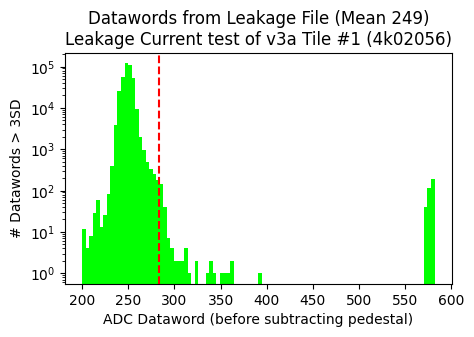

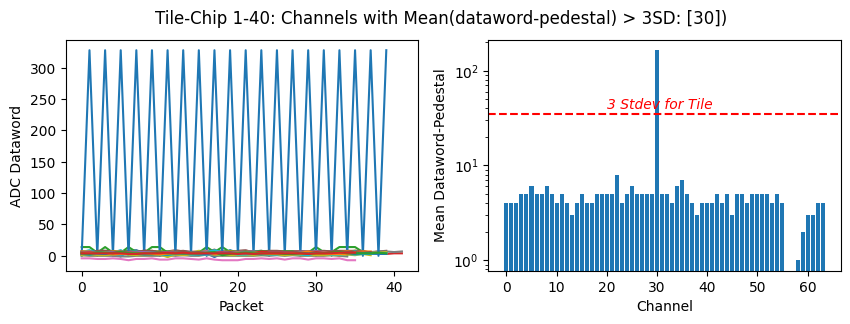

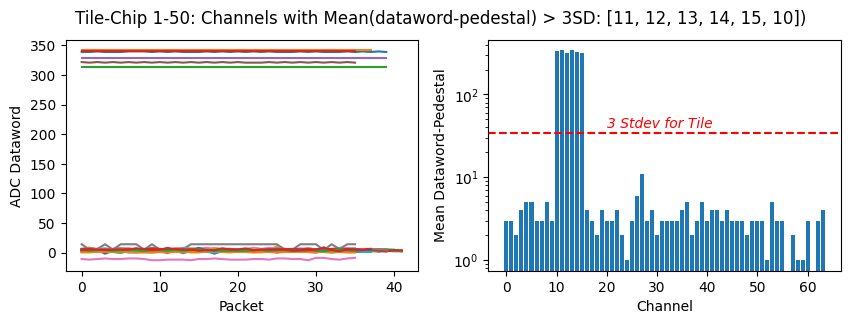

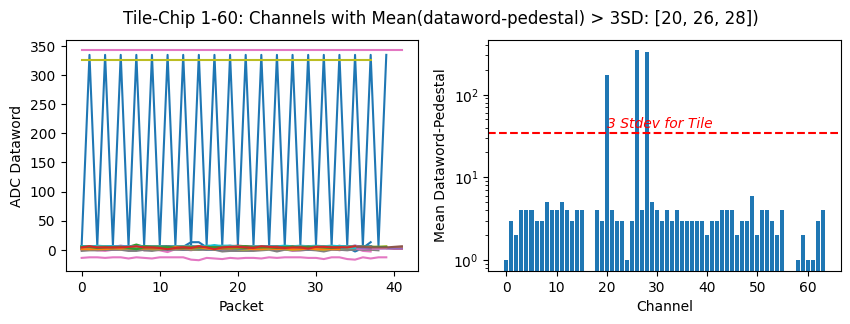

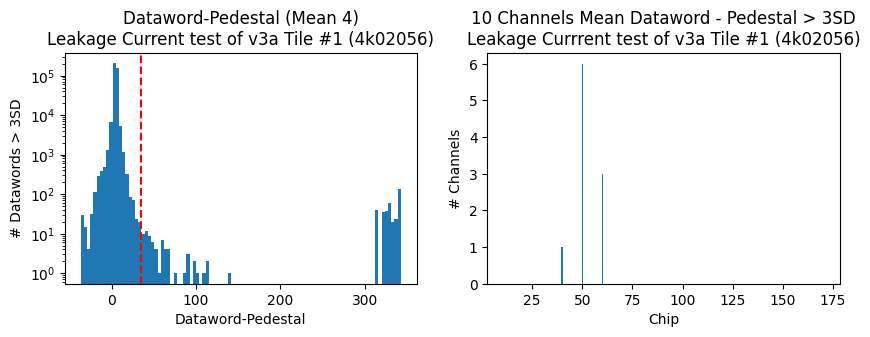

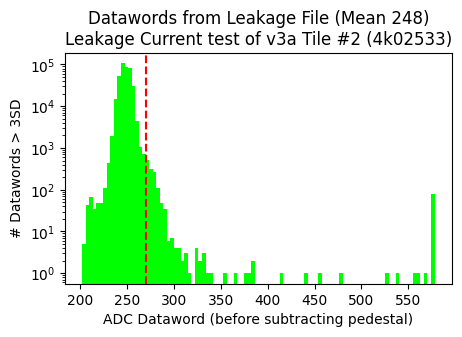

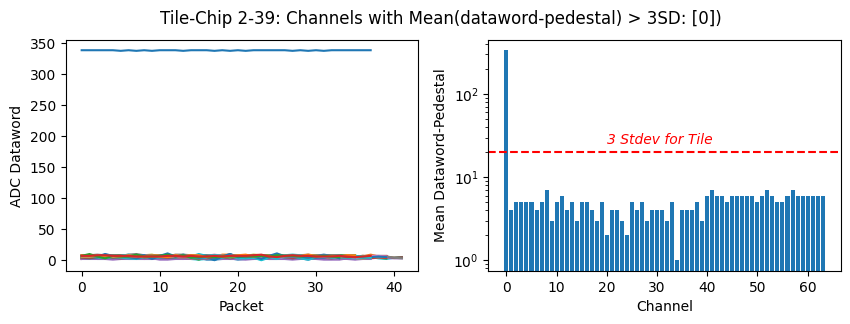

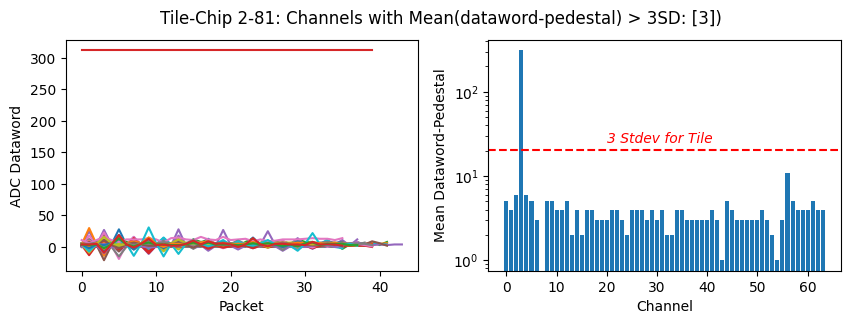

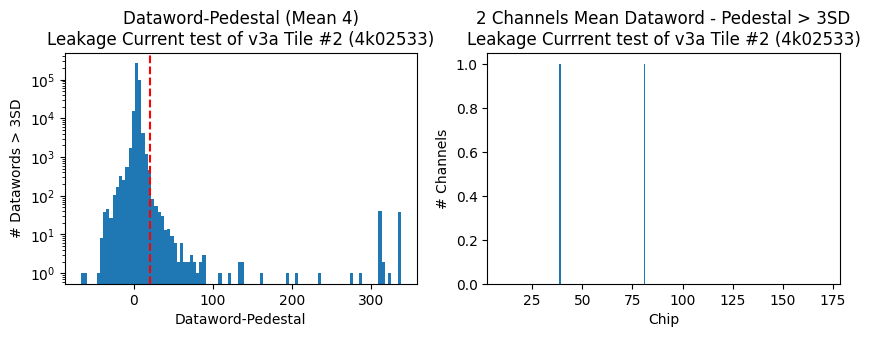

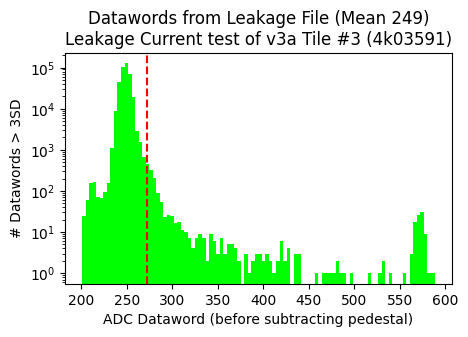

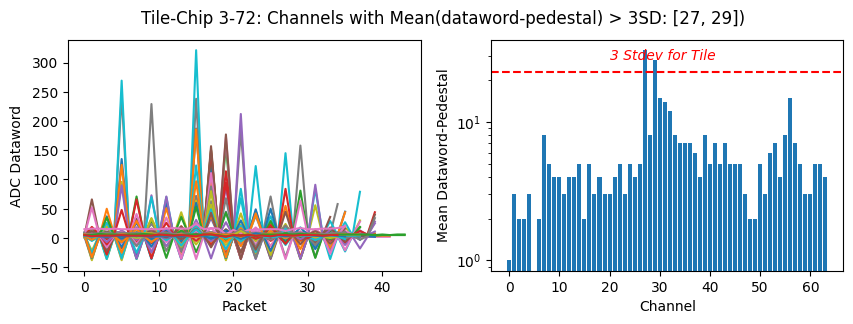

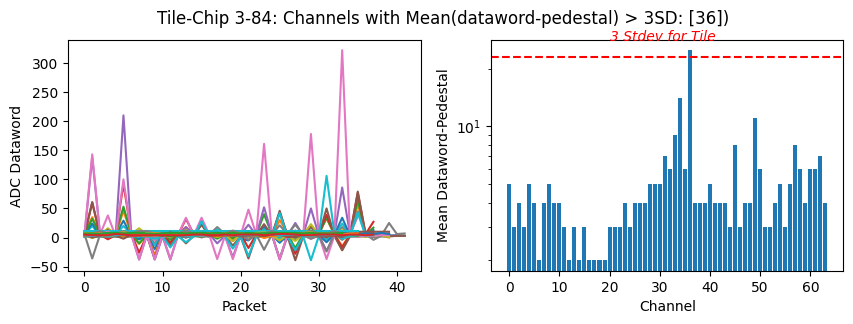

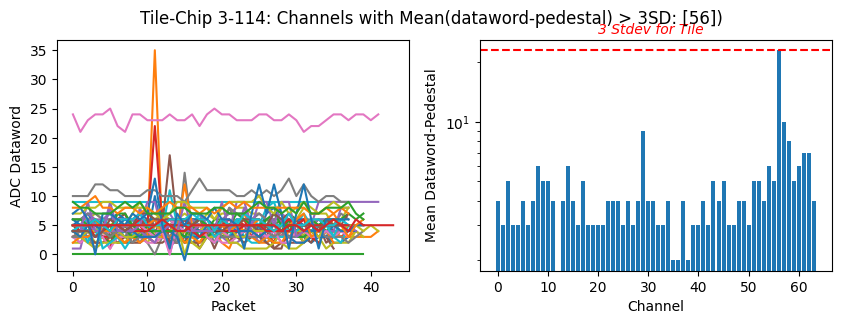

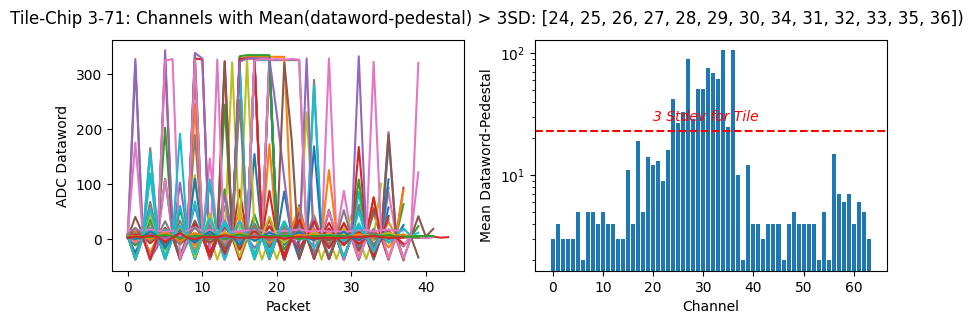

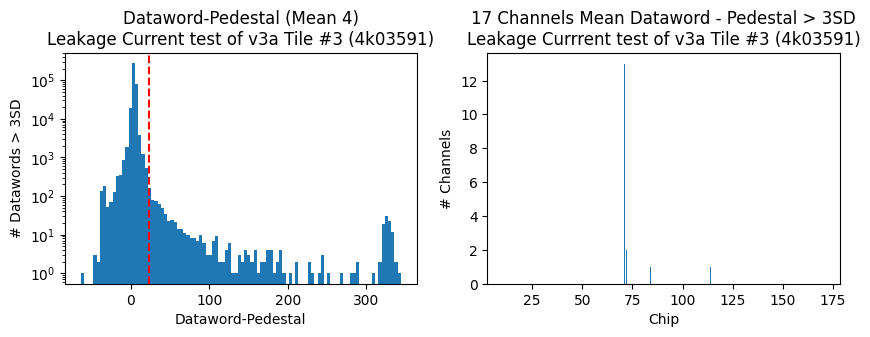

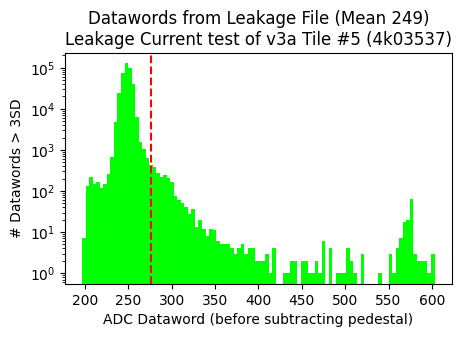

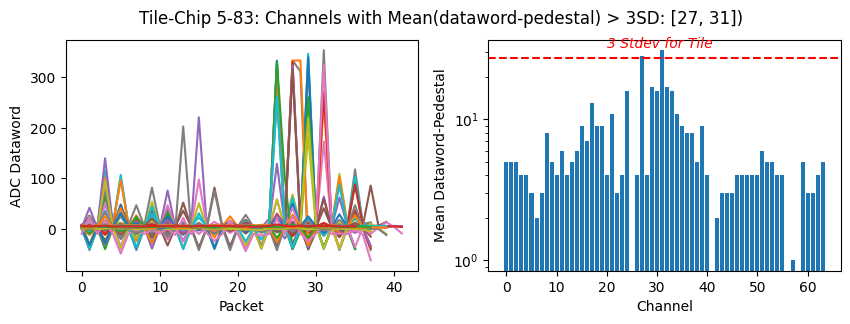

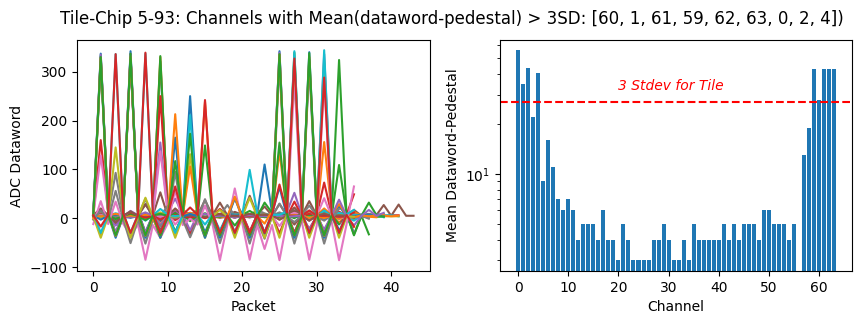

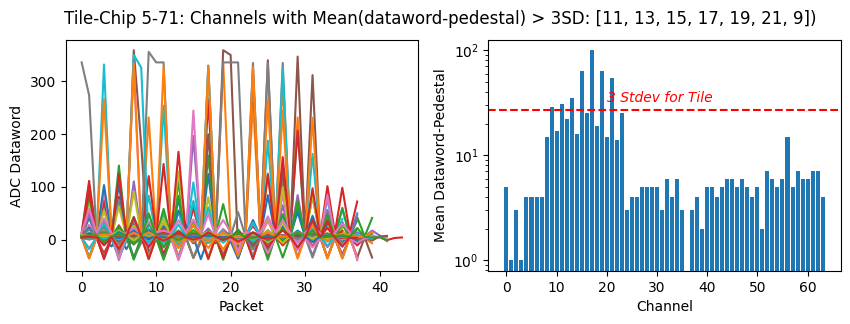

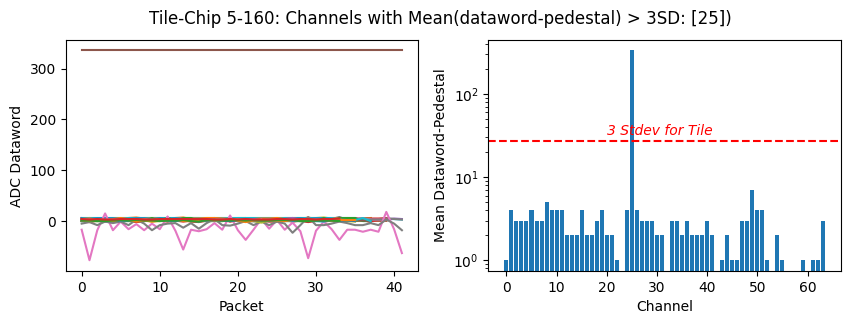

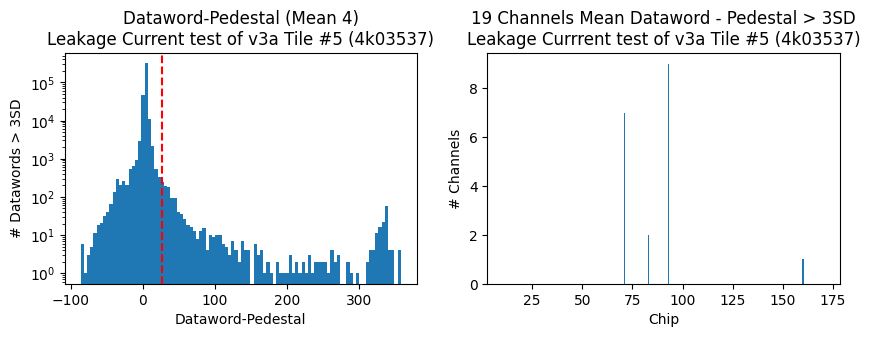

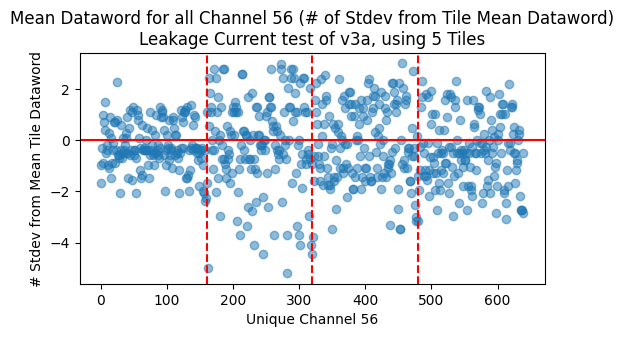

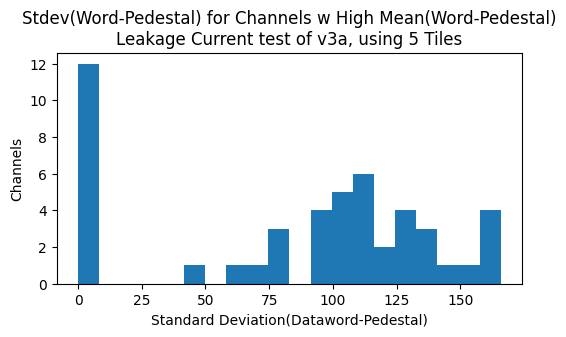

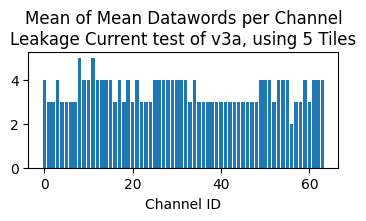

In [5]:
####################
# main
####################

get_pedestals(ntiles)

print(f'Run Statistics for Data File {filename}:')

# get packets from pedestal run data file and check for various attributes
for tile in tiles:
    chip_serial_number = chip_serial_number_list[tile]
    get_data(filename, tile, ig)

print(f'\nFor the {ntiles} tiles tested: \n\t{n_high_file} channels had mean(dataword-pedestal) > {nstdev}Stdev')
print(f'\t{leakage_count} are high leakage candidates (i.e. high word-pedestal AND low stdev)')
print(f'\t{noisy_count} appear to be noisy channels (i.e. high word-pedestal BUT high stdev)')
print(f'\t{n_chan56} were from channel 56')

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(chan56_stdev, marker = 'o', linestyle = 'None', alpha = .5)
ax.set_title(f'Mean Dataword for all Channel 56 (# of Stdev from Tile Mean Dataword)\nLeakage Current test of v3a, using {ntiles} Tiles')
ax.set_xlabel(f'Unique Channel 56')
ax.set_ylabel('# Stdev from Mean Tile Dataword')
plt.axhline(y = 0, color='r', linestyle='-')
plt.axvline(x = 160, color='r', linestyle='--')
plt.axvline(x = 320, color='r', linestyle='--')
plt.axvline(x = 480, color='r', linestyle='--')
plt.show

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(stdev_high_list, bins = 20)
ax.set_title(f'Stdev(Word-Pedestal) for Channels w High Mean(Word-Pedestal)\nLeakage Current test of v3a, using {ntiles} Tiles')
ax.set_xlabel(f'Standard Deviation(Dataword-Pedestal)')
ax.set_ylabel('Channels')
plt.show

for i in range(64):
    mean_of_means.append(mean(means[i]))
    chan_list.append(i)

fig, ax = plt.subplots(figsize=(4, 1.5))
ax.bar(chan_list, mean_of_means)
ax.set_title(f'Mean of Mean Datawords per Channel\nLeakage Current test of v3a, using {ntiles} Tiles')
ax.set_xlabel(f'Channel ID')
plt.show